
========== Results ==========
Selected Section: 0.00125 - 0.01990
 Points: 374
R² of Section: 0.98476

Young's Modulus E: 2867.356 MPa
Poisson's Ratio ν: 0.33346
Shear Modulus G: 1075.157 MPa


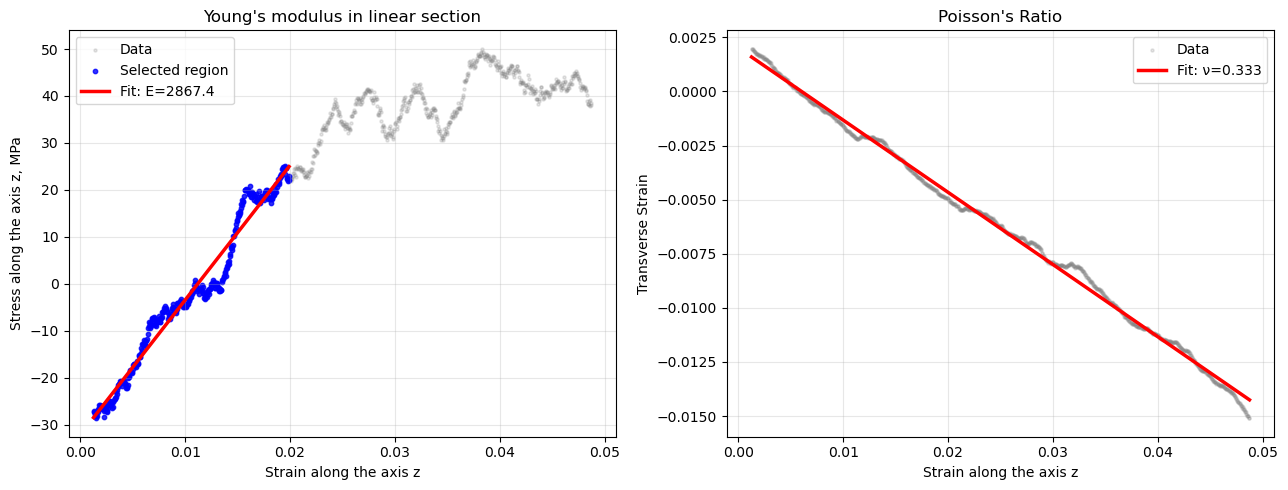

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# 1. Data Loading
# =========================================
data = pd.read_csv(
    "../LAMMPS/stress_strain.dat",
    sep=r"\s+",
    comment="#",
    names=["strain_z", "strain_x", "strain_y", "stress_z"]
)

# =========================================
# 2. Smoothing
# =========================================
def smooth(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode='valid')

strain_z_s = smooth(data["strain_z"].values)
stress_z_s = smooth(data["stress_z"].values)

strain_trans_s = smooth(
    0.5 * (
        data["strain_x"].values +
        data["strain_y"].values
    )
)

# Alignment
n = min(len(strain_z_s), len(stress_z_s), len(strain_trans_s))

strain_z_s = strain_z_s[:n]
stress_z_s = stress_z_s[:n]
strain_trans_s = strain_trans_s[:n]

# =========================================
# 3. Determination of the Linear Section
# =========================================
def find_best_linear_region(x, y,
                            max_strain=0.02,
                            min_strain=0.001,
                            min_fraction=0.35):

    # Search Range Limitation
    mask = (x >= min_strain) & (x <= max_strain)

    x_search = x[mask]
    y_search = y[mask]

    best_score = -1
    best_range = (0, len(x_search))
    start = 0

    min_window = int(len(x_search) * min_fraction)

    for start in range(0,
                       len(x_search) - min_window,
                       3):

        for end in range(start + min_window,
                         len(x_search),
                         3):

            x_win = x_search[start:end]
            y_win = y_search[start:end]

            # Linear Regression
            p = np.polyfit(x_win, y_win, 1)

            y_fit = np.polyval(p, x_win)

            # R²
            ss_res = np.sum((y_win - y_fit)**2)
            ss_tot = np.sum((y_win - np.mean(y_win))**2)

            if ss_tot == 0:
                continue

            r2 = 1 - ss_res / ss_tot

            # Bonus for Window Length
            length_bonus = (
                (end - start) /
                len(x_search)
            ) * 0.02

            score = r2 + length_bonus

            if score > best_score:
                best_score = score

                offset = np.where(mask)[0][0]

                best_range = (
                    start + offset,
                    end + offset
                )

    return best_range, best_score

# =========================================
# 4. Searching of Section
# =========================================
(idx_start,
 idx_end), score = find_best_linear_region(
    strain_z_s,
    stress_z_s,
    max_strain=0.02,
    min_strain=0.001,
)

ez = strain_z_s[idx_start:idx_end]
st = stress_z_s[idx_start:idx_end]
et = strain_trans_s[idx_start:idx_end]

# =========================================
# 5. Young's Modulus
# =========================================
p_e = np.polyfit(ez, st, 1)

E = p_e[0]
b_e = p_e[1]

# =========================================
# 6. Poisson's Ratio
# =========================================
p_nu = np.polyfit(
    strain_z_s,
    strain_trans_s,
    1
)

nu = -p_nu[0]
b_nu = p_nu[1]

# =========================================
# 7. Shear Modulus
# =========================================
G = E / (2 * (1 + nu))

# =========================================
# 8. Display
# =========================================
print("\n========== Results ==========")

print(
    f"Selected Section: "
    f"{ez[0]:.5f} - {ez[-1]:.5f}"
)

print(f" Points: {len(ez)}")

print(f"R² of Section: {score:.5f}")

print(f"\nYoung's Modulus E: {E:.3f} MPa")

print(f"Poisson's Ratio ν: {nu:.5f}")

print(f"Shear Modulus G: {G:.3f} MPa")

print("================================")

# =========================================
# 9. Graphs
# =========================================
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

# -----------------------------------------
# Young's modulus
# -----------------------------------------
ax1.scatter(
    strain_z_s,
    stress_z_s,
    s=5,
    alpha=0.2,
    color='gray',
    label='Data'
)

ax1.scatter(
    ez,
    st,
    s=10,
    alpha=0.8,
    color='blue',
    label='Selected region'
)

ax1.plot(
    ez,
    E * ez + b_e,
    'r',
    linewidth=2.5,
    label=f'Fit: E={E:.1f}'
)

ax1.set_title("Young's modulus in linear section")

ax1.set_xlabel("Strain along the axis z")
ax1.set_ylabel("Stress along the axis z, MPa")

ax1.grid(True, alpha=0.3)

ax1.legend()

# -----------------------------------------
# Poisson's Ratio
# -----------------------------------------
ax2.scatter(
    strain_z_s,
    strain_trans_s,
    s=5,
    alpha=0.2,
    color='gray',
    label='Data'
)

ax2.plot(
    strain_z_s,
    -nu * strain_z_s + b_nu,
    'r',
    linewidth=2.5,
    label=f'Fit: ν={nu:.3f}'
)

ax2.set_title("Poisson's Ratio")

ax2.set_xlabel("Strain along the axis z")
ax2.set_ylabel("Transverse Strain")

ax2.grid(True, alpha=0.3)

ax2.legend()

plt.tight_layout()
plt.show()